## Navier-Stokes Equation using PINNs
### The Equation:
$$ \rho \left( \frac{\partial \mathbf{u}}{\partial t} + \mathbf{u} \cdot \nabla \mathbf{u} \right) = -\nabla p + \mu \nabla^2 \mathbf{u} + \mathbf{f} $$

$$ \nabla \cdot \mathbf{u} = 0 $$
#### Specifying conditions and assumptions
 * The fluid is assumed to be viscous (velocity at stationary walls is assumed zero.) <br>
 * The initial conditions will be specified for t=0 <br>

We set kinematic viscosity $\nu = 0.01$ and density $\rho = 1$. 
The characteristic Reynolds number for this domain (length scale $L=1$, peak initial velocity ~1) is:

$$Re = \frac{UL}{\nu}  = 100$$

This places us in the **laminar-to-transitional regime** — making it tractable for a PINN without resolving turbulent micro-structures. 
At $Re=100$, viscous diffusion dominates over time, so we expect the flow to decay smoothly to rest.

In [2]:
import torch
import torch.nn as nn
import math

device = torch.device('cpu')
nu = 0.01
rho = 1

In [3]:
def sample_points():
    N = 1500
    x = torch.rand(N,1)*2 - 1
    y = torch.rand(N,1)*2 - 1
    t = torch.rand(N,1)*10
    return torch.cat([x,y,t], dim=1)

### Boundary & Initial Conditions

Boundary condition: All four walls enforce $u = v = 0$, the standard condition for a viscous fluid 
in contact with a stationary solid surface.

Initial condition: At $t=0$ we impose:
$$u(x,y,0) = \sin(\pi x)\sin(\pi y), \quad v(x,y,0) = 0$$

This is a smooth and divergence compatible field i.e 
$$\nabla . u = 0$$
it also satisfies no-slip at all walls

In [4]:
def boundary_points():
    N = 1000

    # top(y = 1)
    x = torch.rand(N,1)*2 - 1
    y = torch.ones(N,1)
    t = torch.rand(N,1)*10
    top = torch.cat([x,y,t], dim=1)

    # right (x =1)
    y = torch.rand(N,1)*2 - 1
    x = torch.ones(N,1)
    t = torch.rand(N,1)*10
    right = torch.cat([x,y,t], dim=1)

    # left(x = -1)
    y = torch.rand(N,1)*2 - 1
    x = -torch.ones(N,1)
    t = torch.rand(N,1)*10
    left = torch.cat([x,y,t], dim=1)

    # bottom(y = -1)
    x = torch.rand(N,1)*2 - 1
    y = -torch.ones(N,1)
    t = torch.rand(N,1)*10
    bottom = torch.cat([x,y,t], dim=1)

    return torch.cat([top, right, left, bottom], dim=0)

In [5]:
def initial_points():
    N = 100
    x = torch.linspace(-1,1,N)
    y = torch.linspace(-1,1,N)

    X,Y = torch.meshgrid(x,y,indexing="ij")
    t = torch.zeros_like(X)

    pts = torch.stack([X.reshape(-1),Y.reshape(-1),t.reshape(-1)],dim=1)

    return pts

### Network Architecture

The network maps $(x, y, t) --> (u, v, p)$. Tanh activations are essential here: the physics loss 
requires second-order derivatives via autograd, and `ReLU` would zero those out. 
The width progression (128→64→32) is expressive enough to capture interior flow structure 
without overfitting the sparse collocation points.

In [6]:
class network(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 128),
            nn.Tanh(),
            nn.Linear(128, 64),
            nn.Tanh(),
            nn.Linear(64, 32),
            nn.Tanh(),
            nn.Linear(32, 3)
        )
        
    def forward(self, x):
        return self.net(x)

In [7]:
model = network().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criteria = nn.MSELoss()

### Loss Functions

$$\lambda = \lambda_{\text{physics}} + 10 \cdot \lambda_{\text{Boundary}} + 10 \cdot \lambda_{\text{Initial}}$$

The weight on boundary and initial losses is deliberate since early in training the network must first learn 
the hard constraints before the physics residual is meaningful. Without upweighting, the optimizer tends to 
reduce physics loss by distorting boundary behaviour.

**Pressure gauge:** Incompressible Navier Strokes equation determines pressure only up to a constant. 
The penalty $\bar{p}^2$ anchors mean pressure near zero, preventing the pressure field from drifting randomly during training.

In [13]:
def physics_loss(model, x):
    x.requires_grad_(True)
    pred = model(x)
    u = pred[:,0:1]
    v = pred[:,1:2]
    p = pred[:,2:3]

    du = torch.autograd.grad(u, x, torch.ones_like(u), create_graph= True)[0]
    dv = torch.autograd.grad(v, x, torch.ones_like(v), create_graph= True)[0]
    dp = torch.autograd.grad(p, x, torch.ones_like(p), create_graph= True)[0]
    du_dx, du_dy, du_dt = du[:,0:1], du[:,1:2], du[:, 2:3]
    dv_dx, dv_dy, dv_dt = dv[:,0:1], dv[:,1:2], dv[:, 2:3]
    dp_dx, dp_dy = dp[:,0:1], dp[:,1:2]

    du_dxx = torch.autograd.grad(du_dx, x, torch.ones_like(du_dx), create_graph= True)[0][:, 0:1]
    du_dyy = torch.autograd.grad(du_dy, x, torch.ones_like(du_dy), create_graph= True)[0][:, 1:2]
    dv_dxx = torch.autograd.grad(dv_dx, x, torch.ones_like(dv_dx), create_graph= True)[0][:, 0:1]
    dv_dyy = torch.autograd.grad(dv_dy, x, torch.ones_like(dv_dy), create_graph= True)[0][:, 1:2]

    f_u = du_dt + u*du_dx + v*du_dy + (1/rho)*dp_dx - nu*(du_dxx + du_dyy)
    f_v = dv_dt + u*dv_dx + v*dv_dy + (1/rho)*dp_dy - nu*(dv_dxx + dv_dyy)

    continuity = du_dx + dv_dy
    p_mean = torch.mean(p)
    loss_p = p_mean**2
    
    L1 = criteria(f_u, torch.zeros_like(f_u))
    L2 = criteria(f_v, torch.zeros_like(f_v))
    L3 = criteria(continuity, torch.zeros_like(continuity))
    
    return L1 + L2+L3 +loss_p

In [14]:
def boundary_loss(model, x):
    pred = model(x)
    u = pred[:,0:1]
    v = pred[:,1:2]
    zeros = torch.zeros_like(u)
    return criteria(u, zeros) + criteria(v, zeros)

In [15]:
def init_loss(model, pts):
    pred = model(pts)
    xcoord = pts[:, 0:1]
    ycoord = pts[:, 1:2]
    upred = pred[:,0:1]
    vpred = pred[:,1:2]
    utrue = torch.sin(math.pi*xcoord) * torch.sin(math.pi*ycoord)
    vtrue = torch.zeros_like(utrue)
    return criteria(upred, utrue) + criteria(vpred, vtrue)

In [16]:
losses = []

### Training Loop
The model was trained on 5000 steps keeping higher loss contibutions of boundary and initial losses, and another 5000 steps keeping physics loss's contribution a little higher


In [25]:
epochs = 5000
initial_pts = initial_points()

for epoch in range(epochs):
    sample_pts = sample_points()
    boundry_pts = boundary_points()
    optimizer.zero_grad()
    loss = physics_loss(model, sample_pts) + 15*boundary_loss(model, boundry_pts) + 15*init_loss(model, initial_pts)
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
        print(f'epoch = {epoch}, loss = {loss.item()}')
        losses.append(loss.item())
        

epoch = 0, loss = 0.020407363772392273
epoch = 100, loss = 0.015018458478152752
epoch = 200, loss = 0.012008797377347946
epoch = 300, loss = 0.020030956715345383
epoch = 400, loss = 0.02440238744020462
epoch = 500, loss = 0.021360592916607857
epoch = 600, loss = 0.01732582412660122
epoch = 700, loss = 0.017138008028268814
epoch = 800, loss = 0.024144263938069344
epoch = 900, loss = 0.014020945876836777
epoch = 1000, loss = 0.014248773455619812
epoch = 1100, loss = 0.0166634451597929
epoch = 1200, loss = 0.01709694042801857
epoch = 1300, loss = 0.011413219384849072
epoch = 1400, loss = 0.010000196285545826
epoch = 1500, loss = 0.012068437412381172
epoch = 1600, loss = 0.01744171604514122
epoch = 1700, loss = 0.019969508051872253
epoch = 1800, loss = 0.012181563302874565
epoch = 1900, loss = 0.033888909965753555
epoch = 2000, loss = 0.024170447140932083
epoch = 2100, loss = 0.017328964546322823
epoch = 2200, loss = 0.02012786827981472
epoch = 2300, loss = 0.019352247938513756
epoch = 240

In [50]:
torch.save(model.state_dict(), "navier_stokes_pinn.pth")

### Model Evaluation

After training, the model is evaluated across three criteria:

**Mean continuity residual:** Incompressibility is largely satisfied across the domain<br>
**Max continuity residual:** Localized violation, likely at wall corners where boundary conditions interact<br>
**Mean BC velocity error:** No-slip walls are well enforced on average<br>
**Mean IC error (u):** Initial vortex field is accurately recovered<br>

Lower value of mean continuity residual indicates the network has learned to approximate 
a divergence-free flow field. <br>
The elevated max residual is expected near domain corners, where the no-slip condition on two intersecting walls creates a pressure singularity that is difficult to resolve with a smooth neural network approximation. Further training epochs or corner-refined collocation sampling would reduce this.

In [46]:
model.eval()
sample_pts = sample_points()
sample_pts.requires_grad_(True)
pred = model(sample_pts)
u, v, p = pred[:,0:1], pred[:,1:2], pred[:,2:3]
du = torch.autograd.grad(u, sample_pts, torch.ones_like(u), create_graph=True)[0]
dv = torch.autograd.grad(v, sample_pts, torch.ones_like(v), create_graph=True)[0]
continuity = du[:,0:1] + dv[:,1:2]

print(f"mean continuity residual:  {continuity.abs().mean().item()}")
print(f"max  continuity residual:  {continuity.abs().max().item()}")

with torch.no_grad():
    boundry_pts = boundary_points()
    predb = model(boundry_pts)
    ub, vb = predb[:,0:1], predb[:,1:2]
    print(f"mean boundary velocity error:  {(ub.abs() + vb.abs()).mean().item()}")
    
    pts_ini = initial_points()
    pred_ini = model(pts_ini)
    xi, yi = pts_ini[:,0:1], pts_ini[:,1:2]
    utrue = torch.sin(math.pi * xi) * torch.sin(math.pi * yi)
    ini_error = (pred_ini[:,0:1] - utrue).abs().mean().item()
    print(f"mean initial error (u):  {ini_error}")

mean continuity residual:  0.013283039443194866
max  continuity residual:  1.2919423580169678
mean boundary velocity error:  0.008336435072124004
mean initial error (u):  0.005493460688740015


### Loss Drop

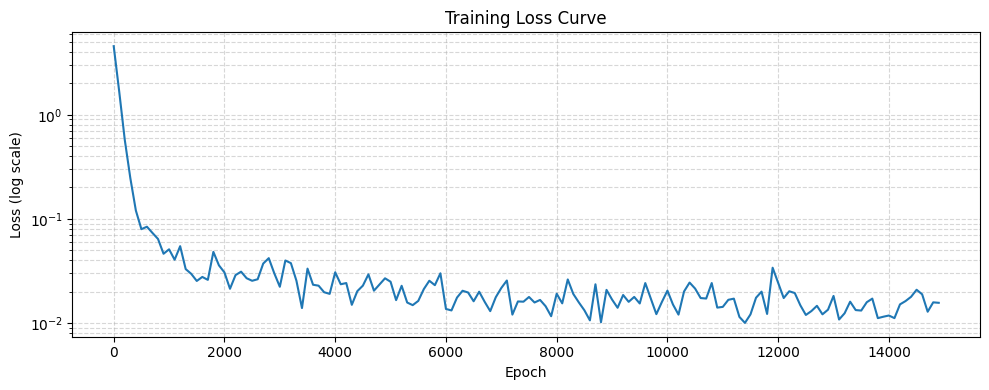

In [47]:
import matplotlib.pyplot as plt

epochs_logged = list(range(0, 15000, 100))

plt.figure(figsize=(10, 4))
plt.plot(epochs_logged, losses)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss (log scale)')
plt.title('Training Loss Curve')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()